# 03 - Container Position and Hardware Analysis

This notebook explores whether container position, hardware type, and size are linked with load patterns and peaks.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = Path("/Users/omkarsomeshwarkondhalkar/Movies/project/eurogate")
DATA_DIR = ROOT / "participant_package"

cols = [
    "EventTime", "AvPowerCons", "container_visit_uuid", "stack_tier", "HardwareType", "ContainerSize",
    "TemperatureSetPoint", "TemperatureAmbient"
]
df = pd.read_csv(DATA_DIR / "reefer_release.csv", sep=";", usecols=cols, parse_dates=["EventTime"], low_memory=False)

# Clean decimal-comma numeric columns
num_cols = ["AvPowerCons", "TemperatureSetPoint", "TemperatureAmbient"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

df["power_kw"] = df["AvPowerCons"] / 1000

print(df.shape)
print("Non-null %:", (df[num_cols + ["power_kw"]].notna().mean() * 100).round(2).to_dict())
df.head()

(3774557, 9)
Non-null %: {'AvPowerCons': 100.0, 'TemperatureSetPoint': 100.0, 'TemperatureAmbient': 100.0, 'power_kw': 100.0}


,container_visit_uuid,HardwareType,EventTime,AvPowerCons,TemperatureSetPoint,TemperatureAmbient,ContainerSize,stack_tier,power_kw
0,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 00:00:00,887.793488,-18.0,9.625000,40.0,1.0,0.887793
1,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 01:00:00,928.909479,-18.0,10.066667,40.0,1.0,0.928909
2,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 02:00:00,929.646456,-18.0,10.250000,40.0,1.0,0.929646
3,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 03:00:00,923.307627,-18.0,10.550000,40.0,1.0,0.923308
4,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 04:00:00,945.029192,-18.0,11.066667,40.0,1.0,0.945029


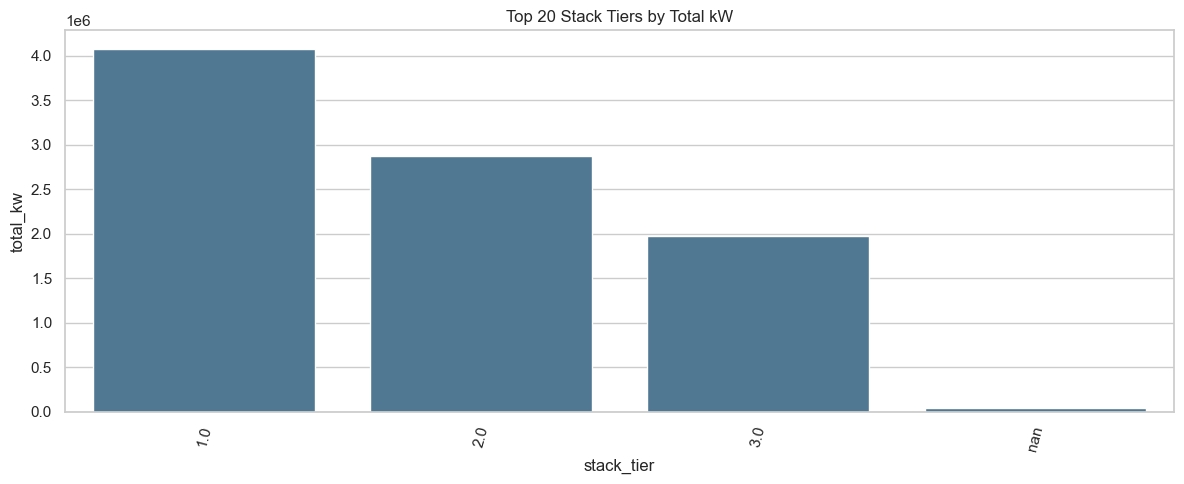

,avg_kw,total_kw,visits
stack_tier,,,
1.0,2.324956,4.078528e+06,17884
2.0,2.387971,2.875187e+06,14570
3.0,2.453914,1.972501e+06,11413
NaN,3.080088,3.841178e+04,12426


In [2]:
# Top stack tiers by energy contribution
rack_stats = (df.groupby("stack_tier", dropna=False)
              .agg(avg_kw=("power_kw", "mean"), total_kw=("power_kw", "sum"), visits=("container_visit_uuid", "nunique"))
              .sort_values("total_kw", ascending=False)
              .head(20))

plt.figure(figsize=(12, 5))
sns.barplot(x=rack_stats.index.astype(str), y=rack_stats["total_kw"], color="#457b9d")
plt.title("Top 20 Stack Tiers by Total kW")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

rack_stats.head(10)

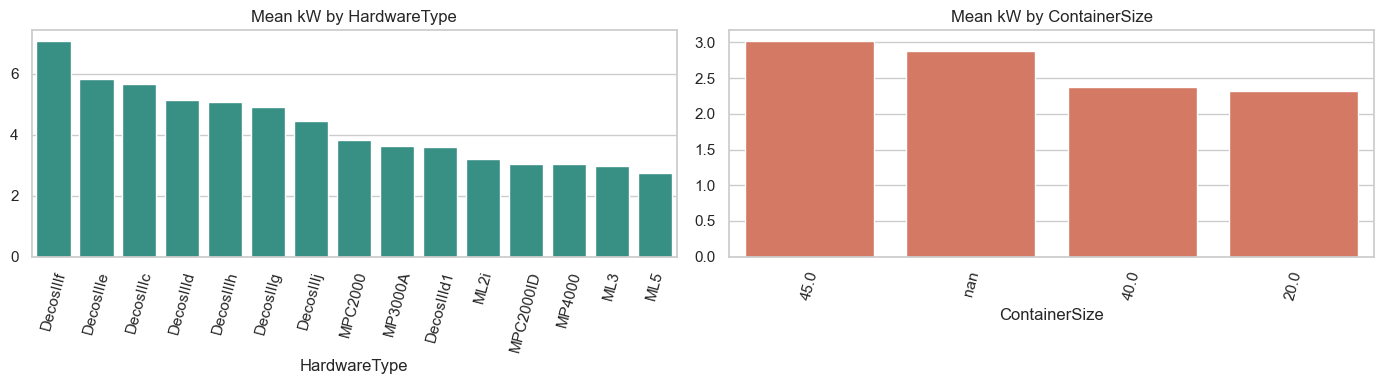

In [3]:
# Hardware and size segment behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hw = df.groupby("HardwareType", dropna=False)["power_kw"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=hw.index.astype(str), y=hw.values, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Mean kW by HardwareType")
axes[0].tick_params(axis="x", rotation=75)

sz = df.groupby("ContainerSize", dropna=False)["power_kw"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=sz.index.astype(str), y=sz.values, ax=axes[1], color="#e76f51")
axes[1].set_title("Mean kW by ContainerSize")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

In [4]:
# Peak-hour cohort analysis
hourly = (df.groupby("EventTime", as_index=False)
          .agg(total_power_kw=("power_kw", "sum"),
               reefer_count=("container_visit_uuid", "nunique"),
               temp_ambient_mean=("TemperatureAmbient", "mean"),
               temp_setpoint_mean=("TemperatureSetPoint", "mean")))

peak_threshold = hourly["total_power_kw"].quantile(0.9)
hourly["is_peak_hour"] = hourly["total_power_kw"] >= peak_threshold

summary = hourly.groupby("is_peak_hour").agg(["mean", "median"])
summary

EventTime                     total_power_kw   
                                      mean              median           mean   
is_peak_hour                                                                    
False        2025-07-05 05:35:45.622851328 2025-07-08 07:30:00    1007.125296  \
True         2025-09-21 22:05:08.204518400 2025-10-17 05:00:00    1603.740948   

                          reefer_count        temp_ambient_mean              
                   median         mean median              mean     median   
is_peak_hour                                                                 
False         1004.519240   432.585427  428.0         12.803320  13.274380  \
True          1571.561421   598.508918  603.0         14.996008  13.736477   

             temp_setpoint_mean            
                           mean    median  
is_peak_hour                               
False                 -0.016120  0.116525  
True                  -0.530967 -0.663301

In [5]:
# Data-health diagnostics: check if many zeros are real or parsing artifacts
zero_share_power = (df["power_kw"] == 0).mean() * 100
nan_share_power = df["power_kw"].isna().mean() * 100
print({"power_kw_zero_pct": round(float(zero_share_power), 3), "power_kw_nan_pct": round(float(nan_share_power), 3)})

hourly_check = (df.groupby("EventTime", as_index=False)
                .agg(total_power_kw=("power_kw", "sum"))
                .sort_values("EventTime"))
print("Hourly zero pct:", round(float((hourly_check["total_power_kw"] == 0).mean() * 100), 3))

hourly_check["total_power_kw"].describe()

{'power_kw_zero_pct': 0.089, 'power_kw_nan_pct': 0.0}
Hourly zero pct: 0.0


count    8403.000000
mean     1066.836561
std       280.189290
min        25.181238
25%       857.536994
50%      1037.777508
75%      1233.877610
max      2111.213573
Name: total_power_kw, dtype: float64